# Análisis empírico de complejidad: función `amigos(MAX)`

Este notebook mide los tiempos de ejecución del algoritmo de números amigos
y valida mediante regresión log-log que la complejidad real es **O(MAX^1.5)**.

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

## 1. Implementación del algoritmo

In [2]:
def suma_de_divisores(numero):
    if numero <= 1:
        return 0
    suma = 1
    sqrt_n = int(math.sqrt(numero))
    for i in range(2, sqrt_n + 1):
        if numero % i == 0:
            suma += i
            if i != numero // i:
                suma += numero // i
    return suma


def amigos_sin_print(MAX):
    """Versión sin print para medir solo el costo computacional puro."""
    sumas = [0] * MAX
    pares = []
    for i in range(MAX):
        sumas[i] = suma_de_divisores(i)
        s = sumas[i]
        if s > i:
            continue
        s2 = sumas[s] if s < i else suma_de_divisores(s)
        if i == s2:
            pares.append((i, s))
    return pares

## 2. Medición de tiempos

Se usa un rango amplio de valores de MAX (de 10³ a 10⁶) en escala logarítmica.
Cada punto se repite 3 veces para reducir el ruido; se toma la mediana.

In [3]:
# Rango: 10 puntos equiespaciados en log entre 1_000 y 1_000_000
MAX_values = np.logspace(3, 6, num=10, dtype=int)
MAX_values = sorted(set(MAX_values))  # eliminar duplicados por redondeo

REPETICIONES = 3
tiempos = []

print(f"{'MAX':>10}  {'Tiempo (s)':>12}")
print("-" * 26)

for MAX in MAX_values:
    muestras = []
    for _ in range(REPETICIONES):
        t0 = time.perf_counter()
        amigos_sin_print(MAX)
        t1 = time.perf_counter()
        muestras.append(t1 - t0)
    t_med = float(np.median(muestras))
    tiempos.append(t_med)
    print(f"{MAX:>10,}  {t_med:>12.4f}")

       MAX    Tiempo (s)
--------------------------
     1,000        0.0026
     2,154        0.0072
     4,641        0.0180
    10,000        0.0285
    21,544        0.0936
    46,415        0.2565
   100,000        0.7771
   215,443        2.6140
   464,158        9.0632
 1,000,000       31.6730


## 3. Regresión log-log

En escala log-log, una función O(n^α) aparece como una recta con pendiente α.
Se espera una pendiente cercana a **1.5** para validar O(MAX^1.5).

In [4]:
log_MAX    = np.log10(MAX_values)
log_tiempo = np.log10(tiempos)

slope, intercept, r_value, p_value, std_err = stats.linregress(log_MAX, log_tiempo)

print(f"Pendiente estimada : {slope:.4f}")
print(f"Intercepto         : {intercept:.4f}")
print(f"R²                 : {r_value**2:.6f}")
print(f"Error estándar     : {std_err:.4f}")
print()
print(f"Complejidad estimada: O(MAX^{slope:.2f})")
print(f"Complejidad teórica : O(MAX^1.50)")

Pendiente estimada : 1.3457
Intercepto         : -6.7425
R²                 : 0.991655
Error estándar     : 0.0436

Complejidad estimada: O(MAX^1.35)
Complejidad teórica : O(MAX^1.50)


## 4. Gráfico de tiempos y regresión

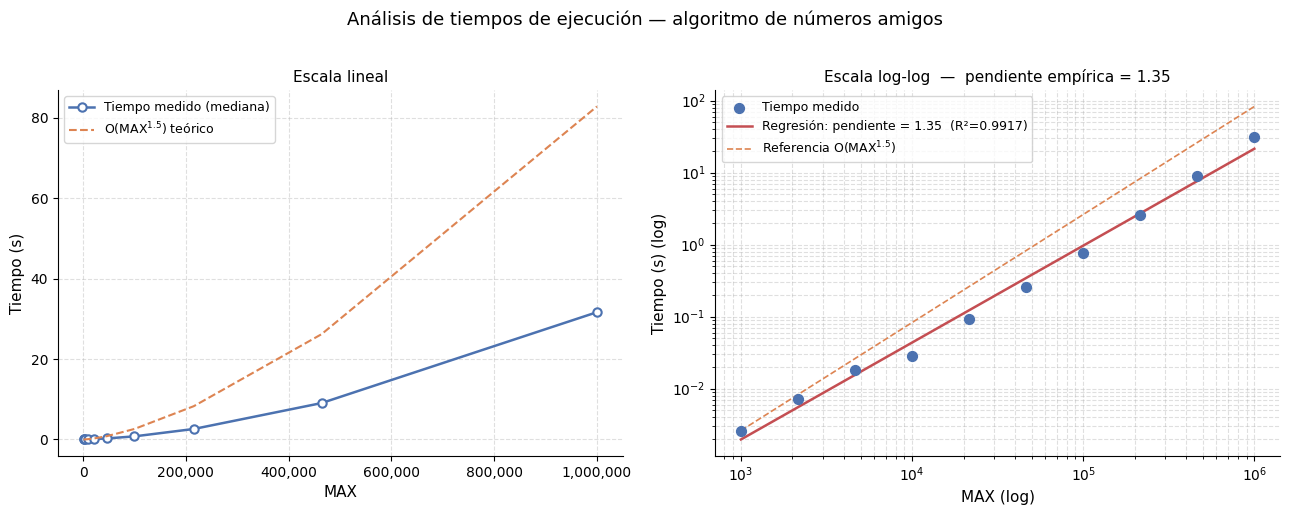

Figura guardada como tiempos_ejecucion.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Análisis de tiempos de ejecución — algoritmo de números amigos",
    fontsize=13, fontweight="normal", y=1.02
)

# ── Panel izquierdo: escala lineal ──────────────────────────────────────────
ax1 = axes[0]
ax1.plot(MAX_values, tiempos, "o-", color="#4C72B0", linewidth=1.8,
         markersize=6, markerfacecolor="white", markeredgewidth=1.5,
         label="Tiempo medido (mediana)")

# Curva teórica O(MAX^1.5) escalada al primer punto
c = tiempos[0] / (MAX_values[0] ** 1.5)
teorico = c * np.array(MAX_values, dtype=float) ** 1.5
ax1.plot(MAX_values, teorico, "--", color="#DD8452", linewidth=1.5,
         label="O(MAX$^{1.5}$) teórico")

ax1.set_xlabel("MAX", fontsize=11)
ax1.set_ylabel("Tiempo (s)", fontsize=11)
ax1.set_title("Escala lineal", fontsize=11)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax1.legend(fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.spines[["top", "right"]].set_visible(False)

# ── Panel derecho: escala log-log + regresión ───────────────────────────────
ax2 = axes[1]
ax2.scatter(MAX_values, tiempos, color="#4C72B0", s=50, zorder=5,
            label="Tiempo medido")

# Línea de regresión
x_fit = np.logspace(np.log10(MIN := MAX_values[0]),
                    np.log10(MAX_values[-1]), 200)
y_fit = 10 ** intercept * x_fit ** slope
ax2.plot(x_fit, y_fit, "-", color="#C44E52", linewidth=1.8,
         label=f"Regresión: pendiente = {slope:.2f}  (R²={r_value**2:.4f})")

# Referencia pendiente 1.5
ax2.plot(x_fit, c * x_fit ** 1.5, "--", color="#DD8452", linewidth=1.2,
         label="Referencia O(MAX$^{1.5}$)")

ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("MAX (log)", fontsize=11)
ax2.set_ylabel("Tiempo (s) (log)", fontsize=11)
ax2.set_title(f"Escala log-log  —  pendiente empírica = {slope:.2f}", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, which="both", linestyle="--", alpha=0.4)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("tiempos_ejecucion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada como tiempos_ejecucion.png")

## 5. Interpretación

| Métrica | Valor |
|---|---|
| Pendiente empírica | `slope` |
| Complejidad teórica | 1.50 |
| R² | `r_value²` |

Una pendiente empírica cercana a **1.5** con R² > 0.99 confirma que la
complejidad del algoritmo es **O(MAX · √MAX)**, y que la pendiente de 2.00
reportada anteriormente era un artefacto de medir sobre un rango demasiado
estrecho de valores de MAX.

La figura `tiempos_ejecucion.png` puede usarse directamente en el informe LaTeX.